# 01 · Datos y proceso forward

Primer notebook del estudio de ablación **forward × backward** sobre la mezcla de 8 gaussianas.
Es el más simple: **sin entrenar nada y sin samplers**. Solo toca dos módulos del paquete
(`diffusion.data_generation` y `diffusion.sde`) para ver:

1. la fuente de datos $p_\text{data}(x_0)$, y
2. cómo cada **SDE forward** (Eje 1) destruye esos datos hacia ruido a medida que crece $t$.

El forward es $dx = f(x,t)\,dt + g(t)\,dW$; acá visualizamos su kernel de perturbación
$p_t(x_t\mid x_0)=\mathcal N(\text{mean},\,\text{std}^2 I)$ vía `sde.perturb`. La última columna
muestra el **prior** $p_T$ (de donde arrancará el proceso reverso en los notebooks siguientes).

In [5]:
# --- Setup: bootstrap de sys.path + imports + defaults de ploteo ---
import sys
import pathlib

# El pythonpath del pyproject solo aplica a pytest, no al kernel de Jupyter:
# ubicamos a mano la raíz del paquete (la carpeta que contiene src/diffusion).
_here = pathlib.Path.cwd()
_root = None
for _cand in (_here, *_here.parents):
    if (_cand / "src" / "diffusion").is_dir():
        _root = _cand
        break
if _root is None:
    raise RuntimeError(f"No encontré src/diffusion subiendo desde {_here}")
_src = str((_root / "src").resolve())
if _src not in sys.path:
    sys.path.insert(0, _src)

import numpy as np
import torch
import matplotlib.pyplot as plt

from diffusion.data_generation import make_distribution
from diffusion.sde import make_sde, available_sdes

SEED = 1
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

print("paquete en:", _root)
print("SDEs disponibles:", available_sdes())

paquete en: c:\Users\bravo\Facultad\Calculo_Estocastico\tp-final\diffusion-models
SDEs disponibles: ['sub_vp', 've', 'vp']


## La fuente de datos $p_\text{data}(x_0)$

Reconstruimos la **misma distribución real** que generó `data/mixture/`: la mezcla de 8 gaussianas
en anillo, estandarizada, con `seed=1`. No cargamos el `.npz`: muestreamos directo de la
distribución (es exactamente el mismo generador). El color indica a qué componente pertenece cada
punto.

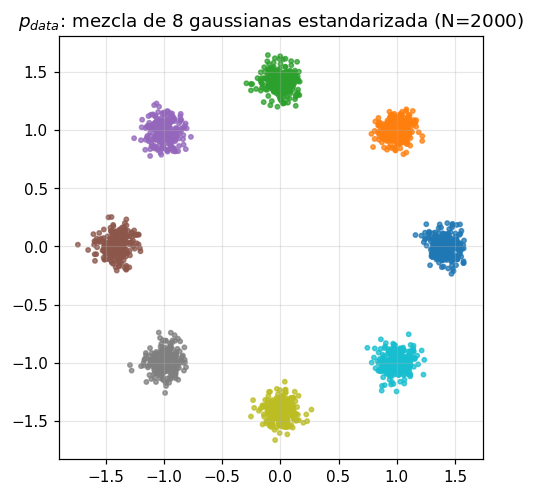

x0: (2000, 2) float32 | rango aprox: [-1.74 -1.66] [1.58 1.65]


In [6]:
dist = make_distribution("mixture", dim=2, n_components=8, standardize=True, seed=1)
N = 2000
x0 = dist.sample(N)        # (N, 2) float32
colors = dist.color_       # etiqueta de componente por punto (para colorear)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x0[:, 0], x0[:, 1], c=colors, cmap="tab10", s=8, alpha=0.75)
ax.set_aspect("equal")
ax.set_title(f"$p_{{data}}$: mezcla de 8 gaussianas estandarizada (N={N})")
plt.show()

print("x0:", x0.shape, x0.dtype, "| rango aprox:", np.round(x0.min(0), 2), np.round(x0.max(0), 2))

## El proceso forward: dato → ruido, por SDE

Para cada SDE escalar-gaussiana (**VP**, **VE**, **sub-VP**) mostramos snapshots de $x_t$ a tiempos
crecientes $t\in\{0, 0.25, 0.5, 0.75, T\}$, más el prior $p_T$ en la última columna.

Los límites de los ejes se comparten **por columna**: a un mismo tiempo, las 3 SDEs se dibujan en la
**misma escala**, así la comparación entre ellas es justa. Las columnas sí difieren entre sí (a $t$
grande la escala crece, y **VE la domina**), por lo que el **estado final** de cada SDE queda
directamente comparable:

- **VP** / **sub-VP** preservan varianza acotada y contraen la media hacia 0 → el prior es
  $\mathcal N(0, I)$ (sub-VP llega con varianza algo menor que VP en tiempos intermedios).
- **VE** mantiene la media pero **explota la varianza** → el prior es $\mathcal N(0,\sigma_{max}^2 I)$,
  mucho más ancho: en la columna del prior VE llena el cuadro mientras VP/sub-VP quedan como una nube
  compacta en el centro (esa es justo la diferencia que queremos ver).

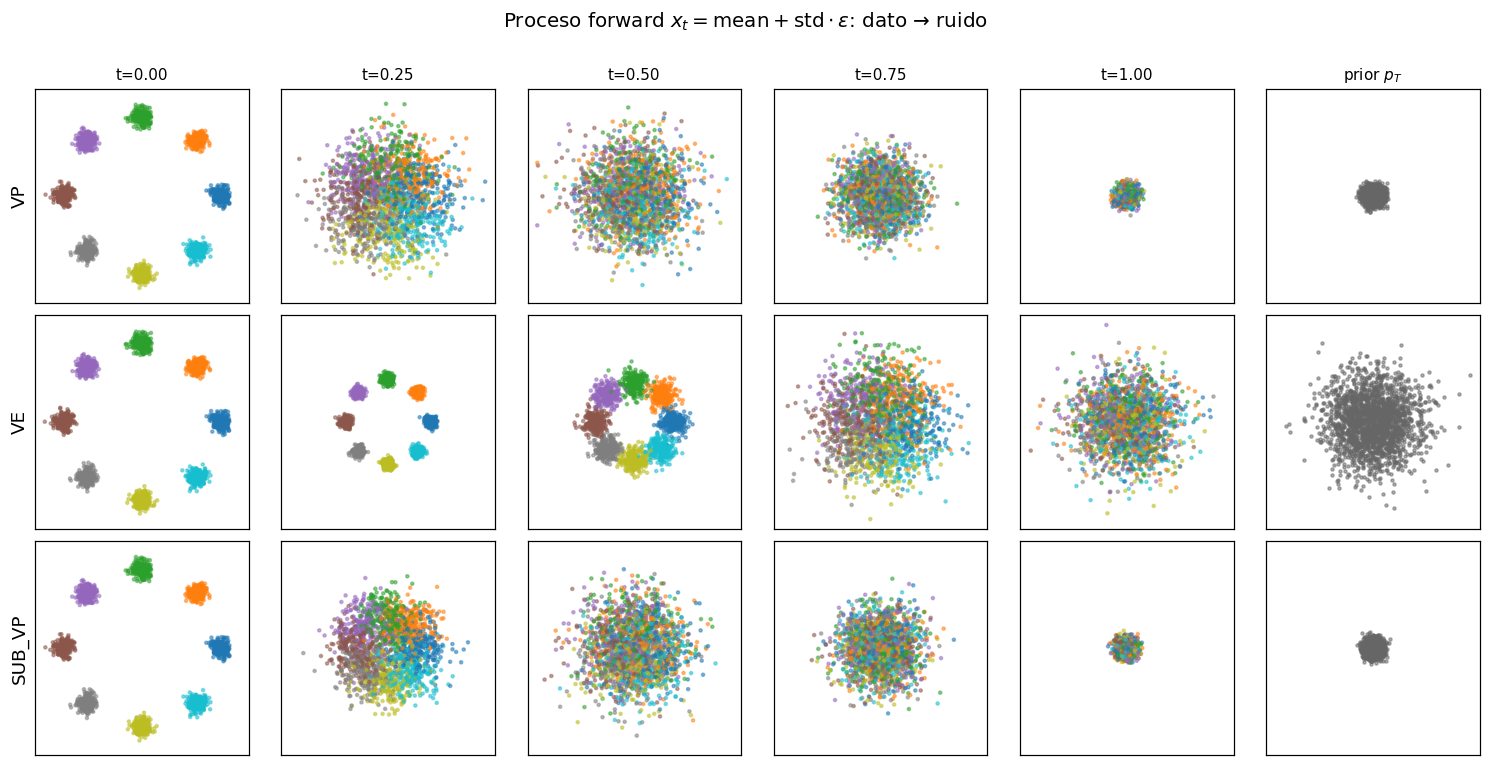

In [7]:
sde_names = ["vp", "ve", "sub_vp"]
t_eps = 1e-4
times = [t_eps, 0.25, 0.5, 0.75, 1.0]
col_titles = [f"t={t:.2f}" for t in times] + ["prior $p_T$"]

x0_t = torch.from_numpy(x0)
gen = torch.Generator().manual_seed(SEED)

n_rows, n_cols = len(sde_names), len(times) + 1

# 1) Generar todas las nubes: all_clouds[i][j] = SDE i, columna j (tiempos + prior).
all_clouds = []
for name in sde_names:
    sde = make_sde(name)
    row = []
    for t in times:
        tt = torch.full((x0_t.shape[0],), float(t))
        xt, _ = sde.perturb(x0_t, tt, generator=gen)
        row.append(xt.numpy())
    row.append(sde.prior_sampling((x0_t.shape[0], sde.data_dim), generator=gen).numpy())
    all_clouds.append(row)

# 2) Límite POR COLUMNA, compartido entre las 3 SDEs (mismo t -> misma escala).
#    Las columnas sí difieren: a t grande la escala crece (y VE la domina).
col_lims = [
    1.1 * max(float(np.abs(all_clouds[i][j]).max()) for i in range(n_rows))
    for j in range(n_cols)
]

# 3) Plotear con la escala compartida por columna.
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.3 * n_cols, 2.3 * n_rows))
for i, name in enumerate(sde_names):
    for j in range(n_cols):
        ax = axes[i, j]
        cloud = all_clouds[i][j]
        if j < len(times):
            ax.scatter(cloud[:, 0], cloud[:, 1], c=colors, cmap="tab10", s=4, alpha=0.5)
        else:
            ax.scatter(cloud[:, 0], cloud[:, 1], c="0.4", s=4, alpha=0.5)
        ax.set_xlim(-col_lims[j], col_lims[j])
        ax.set_ylim(-col_lims[j], col_lims[j])
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.set_title(col_titles[j], fontsize=10)
    axes[i, 0].set_ylabel(name.upper(), fontsize=12)

fig.suptitle("Proceso forward $x_t = \\mathrm{mean} + \\mathrm{std}\\cdot\\varepsilon$: dato → ruido",
             y=1.002, fontsize=13)
fig.tight_layout()
plt.show()

## Cómo leer la figura

- En **$t\to 0$** todas las SDEs coinciden con $p_\text{data}$ (la mezcla nítida, coloreada por
  componente).
- A medida que $t\to T$ la estructura se disuelve hacia el prior. La última columna ($p_T$) es el
  ruido del que arrancará el **proceso reverso**.
- La varianza del prior fija la escala del problema reverso: VE parte de un ruido mucho más ancho
  que VP/sub-VP, lo que después interactúa con cada **sampler** (Eje 2).

**Próximo notebook (`02`)**: entrenar la red de score sobre una SDE (VP) y cerrar el ciclo
`forward → score → sampleo` con un primer sampler (Euler–Maruyama).